#📌 Extracción

In [21]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [22]:
# Cargar los datos desde el archivo JSON
with open('TelecomX_Data.json', 'r') as file:
    data = json.load(file)

df = pd.json_normalize(data)

display(df.head())

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformación

2.1 Conoce el conjunto de datos

In [23]:
# Verificamos la información general del dataset
df.info()

print("\nTipos de datos por columna:\n", df.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

2.2 y 2.3 Comprobación y Manejo de inconsistencias

In [24]:
# Observamos los valores únicos de la columna objetivo 'Churn'
print("Valores únicos en Churn antes de limpiar:", df['Churn'].unique())

# 1. Manejo de strings vacíos en 'Churn'
df['Churn'] = df['Churn'].replace('', np.nan)
df.dropna(subset=['Churn'], inplace=True) # Eliminamos filas sin la variable objetivo

# 2. Corrección del tipo de dato en cargos totales (account.Charges.Total)
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

# Rellenar los valores nulos resultantes en Total con 0
df['account.Charges.Total'] = df['account.Charges.Total'].fillna(0)

# 3. Eliminar registros duplicados
df.drop_duplicates(inplace=True)

print("\nValores nulos después de la limpieza:\n", df.isnull().sum()[df.isnull().sum() > 0])

Valores únicos en Churn antes de limpiar: ['No' 'Yes' '']

Valores nulos después de la limpieza:
 Series([], dtype: int64)


2.4 Columna de cuentas diarias

In [25]:
# Calculamos el valor diario
df['Cuentas_Diarias'] = df['account.Charges.Monthly'] / 30

display(df[['account.Charges.Monthly', 'Cuentas_Diarias']].head())

,account.Charges.Monthly,Cuentas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


2.5 Estandarización y transformación de datos

In [26]:
# Limpiar nombres de columnas reemplazando puntos por guiones bajos
df.columns = df.columns.str.replace('.', '_')

# Convertir "Yes" y "No" a valores binarios (1 y 0) en la variable Churn
df['Churn_binario'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Columnas estandarizadas:\n", df.columns.tolist())

Columnas estandarizadas:
 ['customerID', 'Churn', 'customer_gender', 'customer_SeniorCitizen', 'customer_Partner', 'customer_Dependents', 'customer_tenure', 'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService', 'internet_OnlineSecurity', 'internet_OnlineBackup', 'internet_DeviceProtection', 'internet_TechSupport', 'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract', 'account_PaperlessBilling', 'account_PaymentMethod', 'account_Charges_Monthly', 'account_Charges_Total', 'Cuentas_Diarias', 'Churn_binario']


#📊 Carga y análisis

3.1 Análisis Descriptivo

In [27]:
# Estadísticas descriptivas para variables numéricas
display(df.describe())

,customer_SeniorCitizen,customer_tenure,account_Charges_Monthly,account_Charges_Total,Cuentas_Diarias,Churn_binario
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304,2.158723,0.265370
std,0.368612,24.559481,30.090047,2266.794470,1.003002,0.441561
min,0.000000,0.000000,18.250000,0.000000,0.608333,0.000000
25%,0.000000,9.000000,35.500000,398.550000,1.183333,0.000000
50%,0.000000,29.000000,70.350000,1394.550000,2.345000,0.000000
75%,0.000000,55.000000,89.850000,3786.600000,2.995000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,3.958333,1.000000


3.2 Distribución de evasión

/tmp/ipykernel_215/270295017.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='viridis')


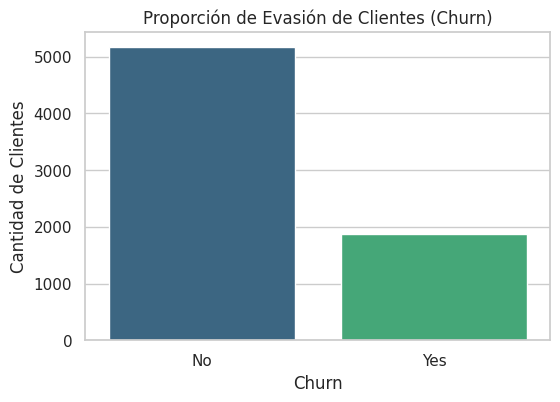

In [28]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', palette='viridis')
plt.title('Proporción de Evasión de Clientes (Churn)')
plt.ylabel('Cantidad de Clientes')
plt.show()

3.3 Recuento de evasión por variables categóricas

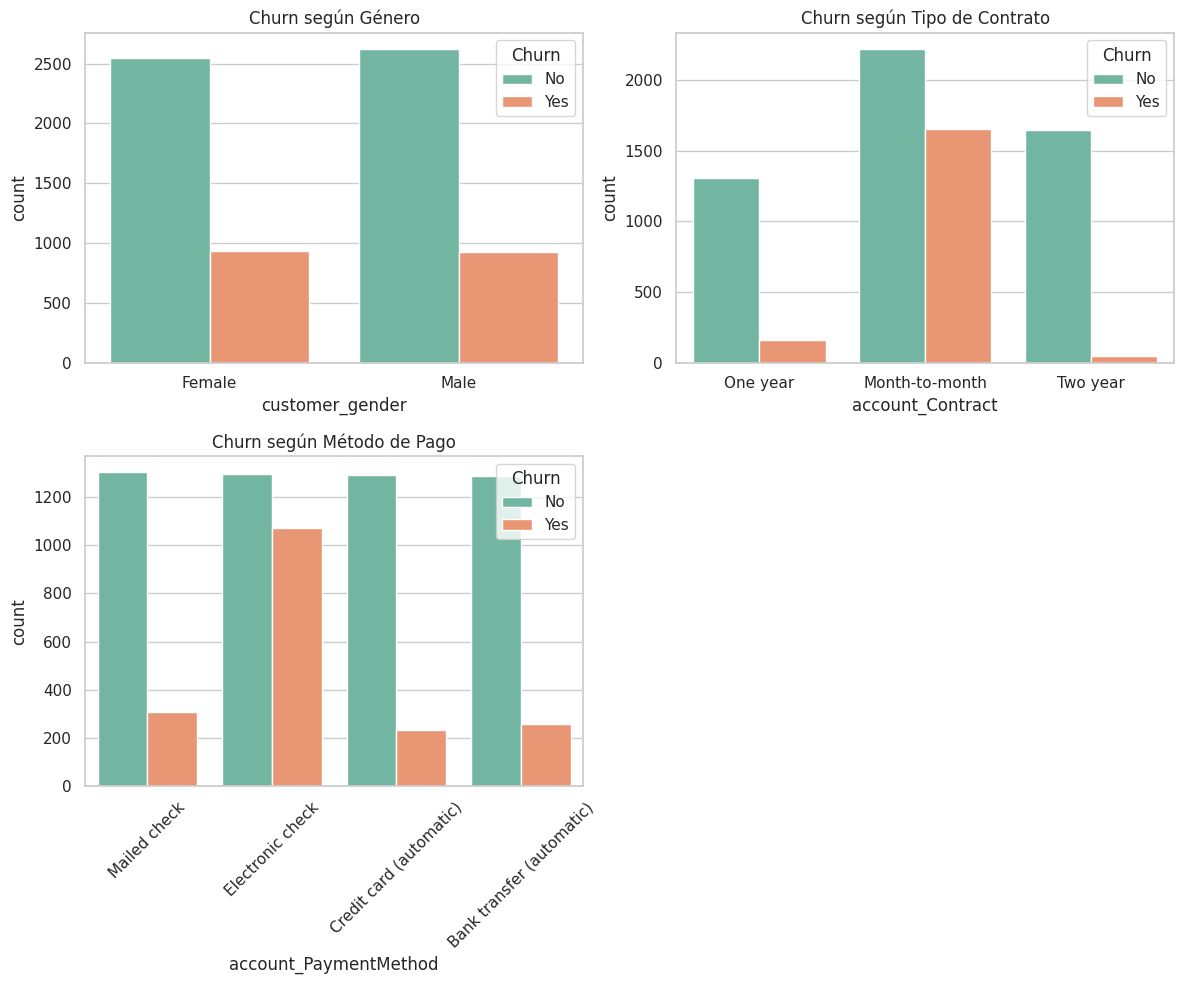

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Churn por Género
sns.countplot(data=df, x='customer_gender', hue='Churn', palette='Set2', ax=axes[0,0])
axes[0,0].set_title('Churn según Género')

# Churn por Tipo de Contrato
sns.countplot(data=df, x='account_Contract', hue='Churn', palette='Set2', ax=axes[0,1])
axes[0,1].set_title('Churn según Tipo de Contrato')

# Churn por Método de Pago
sns.countplot(data=df, x='account_PaymentMethod', hue='Churn', palette='Set2', ax=axes[1,0])
axes[1,0].set_title('Churn según Método de Pago')
axes[1,0].tick_params(axis='x', rotation=45)

fig.delaxes(axes[1,1])

plt.tight_layout()
plt.show()

¡Extra! Análisis de correlación entre variables


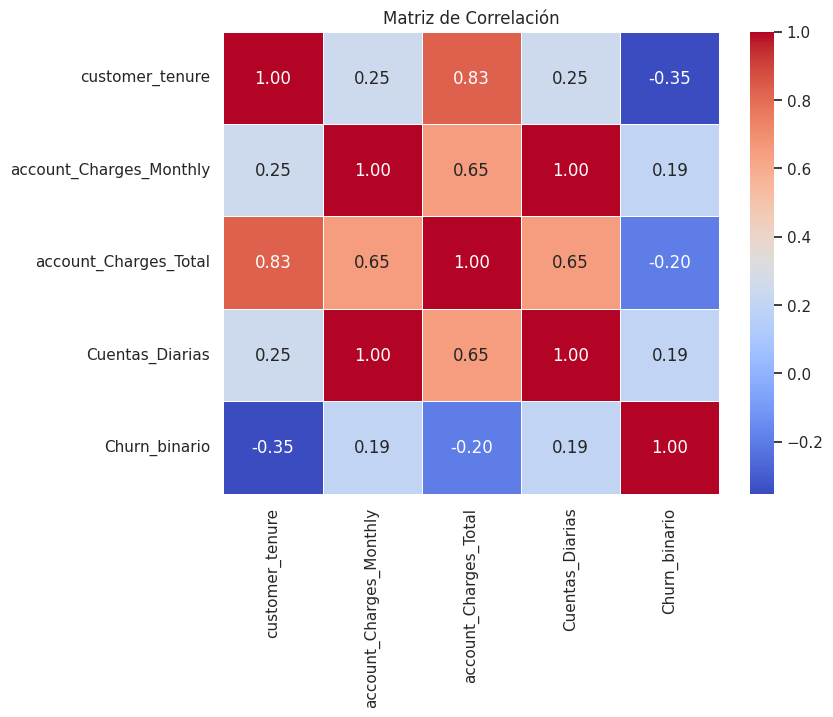

In [30]:
# Seleccionamos variables numéricas relevantes y nuestra variable objetivo binaria
cols_numericas = ['customer_tenure', 'account_Charges_Monthly', 'account_Charges_Total', 'Cuentas_Diarias', 'Churn_binario']

plt.figure(figsize=(8, 6))
correlaciones = df[cols_numericas].corr()
sns.heatmap(correlaciones, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación')
plt.show()

#📄Informe final

## 4. Informe Final

**1. Introducción:**
El presente análisis tiene como objetivo comprender y abordar el problema de la alta tasa de evasión de clientes (Churn) que experimenta Telecom X. A través de la extracción, procesamiento y exploración del conjunto de datos proporcionado, buscamos identificar los factores críticos que impulsan la cancelación de los servicios, con el fin de proporcionar información de valor para la creación de modelos predictivos y el diseño de estrategias de retención.

**2. Limpieza y Tratamiento de Datos:**
Para preparar los datos para el análisis, se realizaron los siguientes pasos:
* **Extracción:** Se cargó el archivo JSON simulando la API y se utilizó `pd.json_normalize` para aplanar la estructura de datos anidados en un DataFrame de Pandas.
* **Limpieza:** Se identificaron y eliminaron registros con valores vacíos (strings nulos) en la variable `Churn`. Asimismo, se forzó la conversión de la columna de cargos totales (`account_Charges_Total`) a numérico, rellenando con 0 los valores nulos resultantes. Finalmente, se eliminaron los datos duplicados, dejando un total de 7043 registros.
* **Transformación:** Se estandarizaron los nombres de las columnas, se reemplazaron los valores "Yes/No" de la columna objetivo por 1 y 0 (`Churn_binario`), y se creó la nueva variable `Cuentas_Diarias` dividiendo el cargo mensual entre 30.

**3. Análisis Exploratorio de Datos:**
Se generaron diversas visualizaciones para entender la distribución de los datos:
* Se creó un gráfico de barras general que muestra la proporción de clientes retenidos frente a los que abandonaron la empresa (aprox. 26.5% de la muestra).
* Se graficó el recuento de evasión cruzado con variables categóricas clave: Género, Tipo de Contrato y Método de Pago.
* De manera complementaria, se elaboró una matriz de correlación en formato mapa de calor para evaluar la relación matemática entre las variables numéricas (`customer_tenure`, `account_Charges_Monthly`, `account_Charges_Total`, `Cuentas_Diarias`) y la probabilidad de abandono (`Churn_binario`).

**4. Conclusiones e Insights:**
A partir del análisis exploratorio, se extrajeron los siguientes hallazgos para entender la evasión:
* El género del usuario no tiene un impacto significativo en la decisión de cancelar el servicio, ya que la distribución es casi equitativa entre hombres y mujeres.
* El tipo de contrato es el factor categórico más determinante: los clientes atados a la modalidad "Mes a mes" (Month-to-month) concentran abrumadoramente la mayor cantidad de cancelaciones en comparación con los contratos anuales o bianuales.
* Los clientes que utilizan el "Cheque electrónico" (Electronic check) como método de pago son mucho más propensos al Churn que aquellos con métodos automáticos.
* Según la matriz de correlación, la antigüedad del cliente (`customer_tenure`) tiene una relación negativa moderada/fuerte (-0.35) con la evasión: los clientes nuevos son los que más se van. Por otro lado, los cargos más altos (mensuales y diarios) incrementan levemente (0.19) la probabilidad de fuga.

**5. Recomendaciones:**
Basados en los insights obtenidos, se sugieren las siguientes estrategias para reducir la evasión:
* **Migración de Contratos:** Diseñar campañas agresivas de incentivos (descuentos, mejoras de velocidad, meses gratis) orientadas específicamente a los usuarios del plan "Mes a mes" para motivarlos a firmar acuerdos a largo plazo (1 o 2 años).
* **Fidelización Temprana:** Puesto que el tiempo de permanencia (`tenure`) es crucial, se debe crear un programa de "Onboarding" excepcional durante los primeros 3 a 6 meses del cliente para fortalecer su lealtad antes de que consideren abandonar.
* **Optimización de Pagos:** Investigar los posibles problemas de experiencia de usuario o insatisfacción relacionados con el cobro por "Cheque electrónico" y promover activamente la afiliación al pago automático (tarjeta de crédito o transferencia) ofreciendo pequeños beneficios.